In [ ]:
print('Hello, World')

Hello, World


In [ ]:
import numpy as np
import math as math
import time as time

### 6.	Reshaping arrays with NumPy:
Create a function that takes a NumPy array of shape (length,width,height) and converts it in to a vector of shape (length*width*height,1). Use the function array.reshape() for this.

In [ ]:
def reshaper(arr):
  l,w,h = arr.shape
  return arr.reshape(l*w*h,1)



###7.	Building a basic mathematical function with NumPy:
- a)	Write a function that returns the sigmoid of a real number x. Use math.exp(x) for the exponential function. Sigmoid(x)=1/(1+exp(-x)).
- b)	Now create a list of 5 values and call your sigmoid function with the list as input. You will get an error because math.exp() only works when input is a real number. It does not work with vectors and matrices. Now create a new function for sigmoid but this time use np.exp() instead of math.exp(). Np.exp() works with all types of inputs including real numbers, vectors and matrices. In deep learning we mostly use matrices and vectors. This is why NumPy is more useful. Call your new function with a vector created by np.array() function.


In [ ]:
def sigmoidReal(x):
  return 1/(1+math.exp(-x))

In [ ]:
x = np.arange(5)
print(x)
print(sigmoidReal(x))

[0 1 2 3 4]


TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
def sigmoid(x):
  return 1/(1 + np.exp(-x))

In [ ]:
print(x)
print(sigmoid(x))

[0 1 2 3 4]
[0.5        0.73105858 0.88079708 0.95257413 0.98201379]


	Implementing a function on a matrix:
Create a function that takes a matrix as input and returns the softmax (by row) of matrix. The softmax function is defined like this:
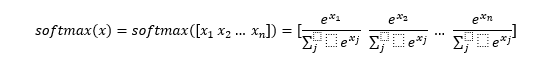

Check if your function is working correctly by using suitable inputs.



In [ ]:
def softmax(x):
  return np.exp(x)/np.sum(np.exp(x),axis=1,keepdims=True)

In [ ]:
# To test the softmax function as intended (for a matrix, row-wise)
b_matrix = np.array([[4, 5, 6, 7], [1, 2, 3, 4]])
print(b_matrix)
print(softmax(b_matrix))


[[4 5 6 7]
 [1 2 3 4]]
[[0.0320586  0.08714432 0.23688282 0.64391426]
 [0.0320586  0.08714432 0.23688282 0.64391426]]


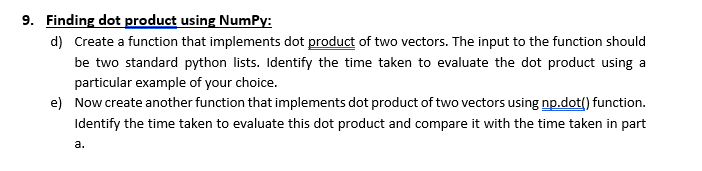

In [ ]:
def dotNumPy(a,b):
  return np.dot(a,b)


In [ ]:
import time

def dot(vec1, vec2):
  if len(vec1) != len(vec2):
    raise ValueError("Vectors must have the same length")

  result = 0
  for i in range(len(vec1)):
    result += vec1[i] * vec2[i]
  return result


In [ ]:
a = np.array([1,2,3])
b = np.array([3,4,5])
start = time.time()
print(f"Manual Dot Product: {dot(a,b)}")
print(f"Time Taken for Manual: {time.time()-start}")
start = time.time()
print(f"Numpy Dot Product: {dotNumPy(a,b)}")
print(f"Time Taken for Numpy: {time.time()-start}")


Manual Dot Product: 26
Time Taken for Manual: 0.00017023086547851562
Numpy Dot Product: 26
Time Taken for Numpy: 0.00017404556274414062


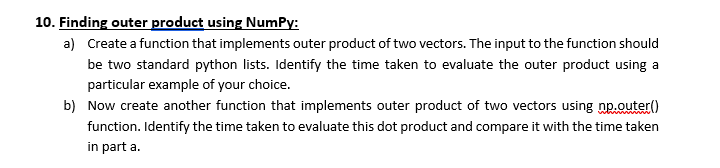

In [ ]:
def outer_product_python_list(vec1, vec2):
  # Get the lengths of the input vectors
  len_vec1 = len(vec1)
  len_vec2 = len(vec2)

  # Initialize a result matrix with zeros
  result = [[0 for _ in range(len_vec2)] for _ in range(len_vec1)]

  # Calculate the outer product using nested loops
  for i in range(len_vec1):
    for j in range(len_vec2):
      result[i][j] = vec1[i] * vec2[j]
  return result

In [ ]:

def outerNumpy(a,b):
  return np.outer(a,b)

# Assuming outer_product_python_list is defined from previous steps
# For comparison, let's redefine the example lists
a_list_comp = [1, 2, 3]
b_list_comp = [4, 5, 6]

# --- Time standard Python list implementation (from part a) ---
start_time_python = time.time()
python_outer_product_result = outer_product_python_list(a_list_comp, b_list_comp)
end_time_python = time.time()
time_taken_python = end_time_python - start_time_python

print(f"Outer product (Python list function):\n{python_outer_product_result}")
print(f"Time taken (Python list function): {time_taken_python:.6f} seconds\n")

# Convert to NumPy arrays for np.outer
a_numpy_comp = np.array(a_list_comp)
b_numpy_comp = np.array(b_list_comp)

# --- Time NumPy's np.outer() ---
start_time_numpy = time.time()
numpy_outer_product_result = outerNumpy(a_numpy_comp, b_numpy_comp)
end_time_numpy = time.time()
time_taken_numpy = end_time_numpy - start_time_numpy

print(f"Outer product (NumPy np.outer()):\n{numpy_outer_product_result}")
print(f"Time taken (NumPy np.outer()): {time_taken_numpy:.6f} seconds\n")

print("\n--- Performance Comparison ---")
if time_taken_numpy < time_taken_python:
    print(f"NumPy's np.outer() is {time_taken_python / time_taken_numpy:.2f} times faster than the Python list implementation.")
elif time_taken_python < time_taken_numpy:
    print(f"The Python list implementation is {time_taken_numpy / time_taken_numpy:.2f} times faster than NumPy's np.outer().")
else:
    print("Both implementations took approximately the same amount of time.")


Outer product (Python list function):
[[4, 5, 6], [8, 10, 12], [12, 15, 18]]
Time taken (Python list function): 0.000064 seconds

Outer product (NumPy np.outer()):
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
Time taken (NumPy np.outer()): 0.000163 seconds


--- Performance Comparison ---
The Python list implementation is 1.00 times faster than NumPy's np.outer().


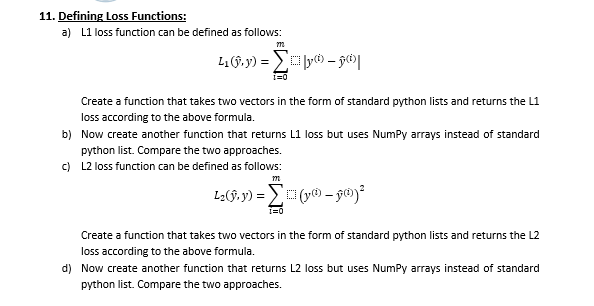

In [ ]:
def lossFunction_L1(y_hat,y):
  loss = 0
  for i in range(len(y_hat)):
    loss += abs(y_hat[i] - y[i])
  return loss

def lossFunction_L1_NumPy(y_hat,y):
  y_hat = np.array(y_hat)
  y = np.array(y)
  return np.sum(np.abs(y_hat - y))

def lossFunction_L2(y_hat,y):
  loss = 0
  for i in range(len(y_hat)):
    loss += (y_hat[i] - y[i])**2
  return loss

def lossFunction_L2_NumPy(y_hat,y):
  y_hat = np.array(y_hat)
  y = np.array(y)
  return np.sum(np.square(y_hat-y))

In [ ]:
a = [7,2,0]
b = [2,4,9]
print(lossFunction_L1(a,b))
print(lossFunction_L1_NumPy(a,b))
print(lossFunction_L2(a,b))
print(lossFunction_L2_NumPy(a,b))

16
16
110
110


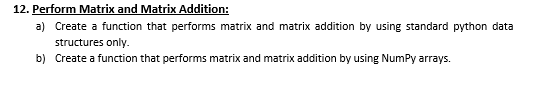

In [ ]:
def addNumpy(x, y):
    x= np.array(x)
    y= np.array(y)
    return x + y

def add(x,y):
    rows = len(x)
    cols = len(x[0])

    # Initialize a result matrix with zeros
    result = [[0 for _ in range(cols)] for _ in range(rows)]

    for i in range(rows):
        for j in range(cols):
            result[i][j] = x[i][j] + y[i][j]

    return result


In [ ]:
a = [[1,2],[3,4]]
b = [[4,5],[6,7]]

print(f"Addition without Numpy: {add(a,b)}")

Addition without Numpy: [[5, 7], [9, 11]]


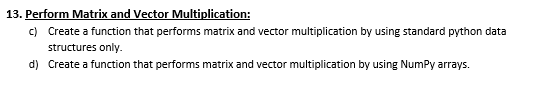

In [ ]:
def matVecMul(a, b):
    r = len(a)
    c = len(a[0])
    o = [0] * r
    for i in range(r):
        s = 0
        for j in range(c):
            s += a[i][j] * b[j]
        o[i] = s
    return o


In [ ]:

def matVecMulNp(a, b):
    a = np.array(a)
    b = np.array(b)
    return a.dot(b)


In [ ]:
a = [[1,2],[3,4]]
b = [5,6]

print("Normal mat-vec:", matVecMul(a, b))
print("NumPy mat-vec:", matVecMulNp(a, b))


Normal mat-vec: [17, 39]
NumPy mat-vec: [17 39]


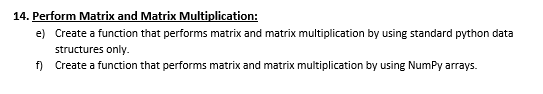

In [ ]:
def matMul(a, b):
    r = len(a)
    c = len(b[0])
    n = len(b)
    o = [[0]*c for _ in range(r)]
    for i in range(r):
        for j in range(c):
            s = 0
            for k in range(n):
                s += a[i][k] * b[k][j]
            o[i][j] = s
    return o


In [ ]:

def matMulNp(a, b):
    a = np.array(a)
    b = np.array(b)
    return a.dot(b)


In [ ]:
c = [[7,8],[9,10]]

print("Normal mat-mat:", matMul(a, c))
print("NumPy mat-mat:", matMulNp(a, c))


Normal mat-mat: [[25, 28], [57, 64]]
NumPy mat-mat: [[25 28]
 [57 64]]
